# 🍜 Bài 2: Nhận Diện Món Ăn Việt Nam & Sinh Công Thức Tự Động
## Vietnamese Food Recognition + Recipe Generation với Deep Learning

---

## 📌 Trình Bày Bài Toán

### Bài toán:
Xây dựng hệ thống **nhận diện món ăn Việt Nam từ ảnh** và **tự động sinh công thức nấu ăn** bằng Deep Learning.

**Input:** Ảnh món ăn Việt Nam  
**Output:**
1. Tên món ăn (Classification)
2. Độ tin cậy (Confidence)
3. Công thức nấu ăn chi tiết (Text Generation)
4. Nguyên liệu ước tính (Ingredient Extraction)

### Tại sao bài toán này thú vị?

1. **Thực tiễn cao**: Ứng dụng trực tiếp vào app ẩm thực, du lịch, sức khỏe
2. **Kết hợp đa mô thức**: CV (nhận diện) + NLP (sinh văn bản) — mở rộng tự nhiên từ Bài 1
3. **Dữ liệu sẵn có**: Tận dụng lại dataset 900 ảnh từ Bài 1 (27 món)
4. **Thách thức thú vị**: Món ăn Việt có visual similarity cao (nhiều món nhìn giống nhau), cần feature extraction tốt
5. **Giá trị văn hóa**: Bảo tồn tri thức ẩm thực truyền thống Việt Nam qua AI

### Tại sao chọn giải pháp này?

- **Bài 1** giải quyết VQA: ảnh + câu hỏi → câu trả lời (reactive)
- **Bài 2** chủ động hơn: chỉ cần ảnh → sinh nội dung phong phú (generative)
- Sử dụng **EfficientNet-B4** (nhẹ, chính xác) + **GPT-style decoder** (sinh công thức)
- Thêm **Contrastive Learning** để phân biệt các món có visual similarity cao
- Pipeline end-to-end có thể deploy thực tế

---

## CELL 1 — Cài đặt thư viện

In [1]:
# ═══════════════════════════════════════════════════════════════
# CELL 1 — CÀI ĐẶT THƯ VIỆN
# ═══════════════════════════════════════════════════════════════
import subprocess, sys

PACKAGES = [
    'torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118',
    'transformers>=4.37.0',
    'peft>=0.7.0',
    'accelerate>=0.26.0',
    'anthropic>=0.21.0',
    'timm>=0.9.0',
    'Pillow>=10.0.0',
    'albumentations>=1.3.1',
    'opencv-python-headless',
    'nltk>=3.8.1',
    'rouge-score>=0.1.2',
    'bert-score>=0.3.13',
    'sacrebleu>=2.3.1',
    'pandas numpy scikit-learn tqdm pyyaml matplotlib seaborn',
    'gradio>=4.0.0',
    'underthesea>=6.8.0',
]

for pkg in PACKAGES:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q'] + pkg.split(), check=False)

import nltk
for d in ['punkt', 'wordnet', 'omw-1.4', 'punkt_tab']:
    nltk.download(d, quiet=True)

print('✅ Cài đặt xong!')

✅ Cài đặt xong!


## CELL 2 — Cấu hình toàn cục

In [2]:
# ═══════════════════════════════════════════════════════════════
# CELL 2 — CẤU HÌNH TOÀN CỤC
# ═══════════════════════════════════════════════════════════════
import os, json, random, time, math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
from collections import defaultdict, Counter

# ── Paths ──────────────────────────────────────────────────────
RAW_IMAGE_DIR   = 'dataset_small'          # Dùng lại dataset từ Bài 1
DATA_DIR        = 'bai2_data'
CHECKPOINT_DIR  = 'bai2_checkpoints'
RESULTS_DIR     = 'bai2_results'
RECIPE_DIR      = 'bai2_data/recipes'

for d in [DATA_DIR, CHECKPOINT_DIR, RESULTS_DIR, RECIPE_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Hyperparams ────────────────────────────────────────────────
SEED          = 42
IMAGE_SIZE    = 224       # EfficientNet-B4 native size
BATCH_SIZE    = 4
EPOCHS        = 30
LR            = 3e-4
WEIGHT_DECAY  = 1e-4
PATIENCE      = 7
GRAD_CLIP     = 1.0
MAX_RECIPE_LEN = 256      # Độ dài tối đa công thức sinh ra
TEMPERATURE   = 0.8       # Sampling temperature cho recipe generation
TOP_K         = 50        # Top-k sampling
CONTRASTIVE_TEMP = 0.07   # Temperature cho contrastive loss

# ── Device ─────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = DEVICE.type == 'cuda'

# ── Seed ───────────────────────────────────────────────────────
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if DEVICE.type == 'cuda':
    torch.cuda.manual_seed_all(SEED)

print(f'Device: {DEVICE}')
print(f'Image size: {IMAGE_SIZE}x{IMAGE_SIZE}')
print(f'Batch size: {BATCH_SIZE}')

Device: cpu
Image size: 224x224
Batch size: 4


## CELL 3 — Xây dựng Recipe Knowledge Base (Cơ sở tri thức công thức)

In [3]:
# ═══════════════════════════════════════════════════════════════
# CELL 3 — RECIPE KNOWLEDGE BASE
# Cơ sở tri thức công thức cho 27 món ăn Việt Nam
# ═══════════════════════════════════════════════════════════════

RECIPE_KNOWLEDGE_BASE = {
    "Pho": {
        "ten_mon": "Phở",
        "nguon_goc": "Miền Bắc Việt Nam",
        "mo_ta": "Món súp nước dùng bò hoặc gà với bánh phở tươi, thịt bò thái lát và rau thơm.",
        "nguyen_lieu": [
            "500g xương bò", "300g thịt bò thái lát", "400g bánh phở tươi",
            "1 củ hành tây", "1 nhánh gừng", "3 cái hoa hồi", "2 thanh quế",
            "Hành lá, ngò gai, rau húng", "Chanh, ớt, tương hoisin",
            "Muối, nước mắm, đường phèn"
        ],
        "cach_lam": [
            "Bước 1 - Nấu nước dùng: Chần xương bò qua nước sôi 5 phút rồi rửa sạch. Cho xương vào nồi 3 lít nước, đun sôi rồi hạ lửa nhỏ ninh 4-6 giờ.",
            "Bước 2 - Tạo hương vị: Nướng hành tây và gừng trên bếp than cho thơm. Rang hoa hồi và quế trên chảo khô. Cho tất cả vào nồi nước dùng cùng đường phèn và nước mắm.",
            "Bước 3 - Chuẩn bị: Trần bánh phở qua nước sôi. Thịt bò thái mỏng, ướp chút muối tiêu.",
            "Bước 4 - Trình bày: Cho bánh phở vào tô, xếp thịt bò lên trên. Chan nước dùng sôi để chín thịt. Thêm hành lá, ngò gai, rau húng.",
            "Bước 5 - Thưởng thức: Ăn kèm chanh, ớt tươi, tương hoisin và tương ớt."
        ],
        "meo_nau": "Nước dùng ngon nhất khi ninh xương ít nhất 4 giờ. Thêm vài cái đinh hương để tăng hương thơm.",
        "thoi_gian": "6-8 giờ",
        "do_kho": "Trung bình"
    },
    "Bun bo": {
        "ten_mon": "Bún bò Huế",
        "nguon_goc": "Huế, Miền Trung",
        "mo_ta": "Món bún nước dùng bò đậm đà, cay nồng đặc trưng xứ Huế với sả và mắm ruốc.",
        "nguyen_lieu": [
            "500g bắp bò", "300g chả cua/giò heo", "400g bún tươi",
            "4 cây sả", "2 muỗng mắm ruốc Huế", "2 muỗng ớt bột",
            "Hành tím, tỏi, gừng", "Rau sống: bắp chuối, rau muống, giá",
            "Nước mắm, muối, đường"
        ],
        "cach_lam": [
            "Bước 1: Luộc bắp bò và giò heo cho mềm (khoảng 2 giờ), để nguội rồi thái miếng vừa ăn.",
            "Bước 2: Phi thơm hành tím, tỏi, sả với dầu ăn. Thêm mắm ruốc và ớt bột, xào đều.",
            "Bước 3: Cho hỗn hợp gia vị vào nồi nước dùng, nêm nếm với nước mắm, muối, đường.",
            "Bước 4: Trần bún qua nước sôi, cho vào tô. Xếp thịt bò, chả cua lên trên.",
            "Bước 5: Chan nước dùng nóng, thêm ớt bột sa tế. Ăn kèm rau sống và chanh."
        ],
        "meo_nau": "Mắm ruốc Huế chính hiệu là bí quyết. Không nấu mắm ruốc quá lâu sẽ mất mùi thơm đặc trưng.",
        "thoi_gian": "3-4 giờ",
        "do_kho": "Trung bình"
    },
    "Com tam": {
        "ten_mon": "Cơm tấm",
        "nguon_goc": "Miền Nam Việt Nam (Sài Gòn)",
        "mo_ta": "Cơm từ gạo tấm (gạo vỡ) ăn kèm sườn nướng, bì, chả, trứng ốp la và mỡ hành.",
        "nguyen_lieu": [
            "400g gạo tấm", "500g sườn non", "200g bì (da heo+thính)",
            "4 quả trứng", "100g mỡ hành",
            "Nước mắm pha (chanh, tỏi, ớt, đường)",
            "Sả, tỏi, hành tím để ướp", "Cà chua, dưa leo trang trí"
        ],
        "cach_lam": [
            "Bước 1 - Ướp sườn: Ướp sườn với sả, tỏi, hành tím, nước mắm, đường, dầu hào ít nhất 2 giờ.",
            "Bước 2 - Nướng sườn: Nướng sườn trên than hoa hoặc lò nướng ở 200°C, lật đều cho vàng đều hai mặt.",
            "Bước 3 - Nấu cơm tấm: Vo gạo tấm sạch, nấu như cơm thường. Cơm chín tơi, không bị nhão.",
            "Bước 4 - Làm mỡ hành: Phi hành lá cùng mỡ heo cho thơm, rưới lên cơm.",
            "Bước 5 - Bày biện: Xới cơm ra đĩa, xếp sườn, bì, chả, trứng ốp la. Rưới nước mắm pha."
        ],
        "meo_nau": "Ngâm gạo tấm 30 phút trước khi nấu để cơm chín đều. Sườn nướng than hoa ngon hơn lò nướng.",
        "thoi_gian": "2-3 giờ",
        "do_kho": "Dễ"
    },
    "Banh mi": {
        "ten_mon": "Bánh mì",
        "nguon_goc": "Toàn quốc (đặc trưng Sài Gòn)",
        "mo_ta": "Bánh mì baguette Việt Nam kẹp thịt nguội, pate, chả, rau thơm và đồ chua.",
        "nguyen_lieu": [
            "1 ổ bánh mì Việt Nam", "50g pate gan", "100g thịt nguội/xá xíu",
            "50g chả lụa", "Đồ chua (cà rốt + củ cải ngâm giấm)",
            "Dưa leo thái lát", "Ngò rí, hành lá",
            "Tương ớt, tương hoisin", "Bơ (tuỳ chọn)"
        ],
        "cach_lam": [
            "Bước 1 - Làm đồ chua: Bào sợi cà rốt và củ cải, trộn với giấm, đường, muối. Ngâm 30 phút.",
            "Bước 2 - Chuẩn bị nhân: Thái mỏng thịt nguội, xá xíu, chả lụa. Chuẩn bị pate gan.",
            "Bước 3 - Nướng bánh: Nướng bánh mì trong lò 180°C 3-5 phút cho vỏ giòn.",
            "Bước 4 - Kẹp nhân: Rạch bánh theo chiều dọc. Phết pate và bơ vào trong.",
            "Bước 5 - Hoàn thiện: Xếp thịt nguội, chả, đồ chua, dưa leo, ngò rí. Rưới tương ớt."
        ],
        "meo_nau": "Bánh mì ngon nhất khi vỏ còn giòn, nhân vừa ráo. Đồ chua ngâm trước 1 ngày sẽ ngon hơn.",
        "thoi_gian": "30 phút",
        "do_kho": "Rất dễ"
    },
    "Goi cuon": {
        "ten_mon": "Gỏi cuốn",
        "nguon_goc": "Miền Nam Việt Nam",
        "mo_ta": "Cuốn rau tươi, tôm, thịt luộc trong bánh tráng mỏng, ăn kèm nước chấm tương đậu phộng.",
        "nguyen_lieu": [
            "12 tờ bánh tráng", "300g tôm sú", "200g thịt ba chỉ luộc",
            "200g bún sợi nhỏ", "Rau: xà lách, húng lủi, tía tô, hẹ",
            "Nước chấm: tương hoisin, tương đậu phộng, tỏi, ớt"
        ],
        "cach_lam": [
            "Bước 1: Luộc tôm và thịt ba chỉ chín tới. Bóc vỏ tôm, thái thịt mỏng.",
            "Bước 2: Trần bún qua nước sôi, chuẩn bị rau sạch.",
            "Bước 3 - Cuốn: Nhúng bánh tráng vào nước cho mềm. Đặt lên mặt phẳng.",
            "Bước 4: Xếp rau, bún, thịt, tôm lên 1/3 tờ bánh. Gập 2 mép vào, cuốn chặt tay.",
            "Bước 5 - Pha nước chấm: Trộn tương hoisin, bơ đậu phộng, nước ấm, tỏi, ớt bằm."
        ],
        "meo_nau": "Nhúng bánh tráng đừng quá lâu (2-3 giây) để không bị rách khi cuốn. Rau phải khô ráo.",
        "thoi_gian": "45 phút",
        "do_kho": "Dễ"
    },
    "Banh xeo": {
        "ten_mon": "Bánh xèo",
        "nguon_goc": "Miền Trung & Nam Việt Nam",
        "mo_ta": "Bánh crepe giòn bột gạo nghệ, nhân tôm thịt giá đỗ, ăn cuốn rau sống với nước mắm chua ngọt.",
        "nguyen_lieu": [
            "300g bột gạo", "1 muỗng cà phê nghệ bột", "400ml nước cốt dừa",
            "300g tôm", "200g thịt ba chỉ", "200g giá đỗ",
            "Hành tím, hành lá", "Rau sống ăn kèm: xà lách, diếp cá, tía tô",
            "Nước mắm chua ngọt pha sẵn"
        ],
        "cach_lam": [
            "Bước 1 - Pha bột: Trộn bột gạo, nghệ, nước cốt dừa, nước lọc thành bột lỏng. Để bột nghỉ 30 phút.",
            "Bước 2 - Chuẩn bị nhân: Xào tôm và thịt với hành tím cho thơm.",
            "Bước 3 - Đổ bánh: Đun nóng chảo trên lửa lớn, phết dầu. Đổ một muôi bột, lắc tròn.",
            "Bước 4 - Cho nhân: Xếp tôm, thịt, giá đỗ lên nửa bánh. Đậy vung 2 phút.",
            "Bước 5: Gập đôi bánh, lấy ra đĩa. Ăn cuốn với rau sống và chấm nước mắm chua ngọt."
        ],
        "meo_nau": "Chảo phải thật nóng và nhiều dầu. Lửa lớn để bánh giòn, đừng đậy vung quá lâu.",
        "thoi_gian": "1 giờ",
        "do_kho": "Trung bình"
    },
    "Bun rieu": {
        "ten_mon": "Bún riêu cua",
        "nguon_goc": "Miền Bắc Việt Nam",
        "mo_ta": "Bún nước dùng cua đồng ngọt thanh với riêu cua, cà chua, đậu phụ và rau sống.",
        "nguyen_lieu": [
            "500g cua đồng xay", "400g bún tươi", "200g cà chua",
            "100g đậu phụ", "50g mắm tôm", "Trứng gà",
            "Hành tím, dầu điều", "Rau sống: rau muống, bắp chuối, giá"
        ],
        "cach_lam": [
            "Bước 1: Lọc nước cua qua rây, tách riêu cua và nước dùng.",
            "Bước 2: Đun nước cua lên, khuấy nhẹ theo 1 chiều cho riêu nổi lên. Vớt riêu ra.",
            "Bước 3: Phi hành tím với dầu điều, cho cà chua vào xào nhừ, nêm mắm tôm.",
            "Bước 4: Cho cà chua vào nồi nước dùng cua, nêm nếm vừa ăn. Thêm đậu phụ chiên.",
            "Bước 5: Cho bún vào tô, xếp riêu cua, đậu phụ, chan nước dùng. Ăn với rau sống."
        ],
        "meo_nau": "Khuấy theo một chiều khi nấu nước cua để riêu tụ thành mảng lớn đẹp hơn.",
        "thoi_gian": "1.5 giờ",
        "do_kho": "Trung bình"
    },
    "Ca kho to": {
        "ten_mon": "Cá kho tộ",
        "nguon_goc": "Miền Nam Việt Nam",
        "mo_ta": "Cá kho trong nồi đất sét với nước dừa, nước mắm, đường tạo màu nâu đậm và vị đậm đà.",
        "nguyen_lieu": [
            "600g cá basa hoặc cá trê", "200ml nước dừa tươi",
            "3 muỗng nước mắm ngon", "2 muỗng đường",
            "Tỏi, ớt, tiêu, hành tím", "Nước màu (kẹo đắng)"
        ],
        "cach_lam": [
            "Bước 1 - Ướp cá: Ướp cá với nước mắm, tỏi, tiêu, hành tím 30 phút.",
            "Bước 2 - Làm nước màu: Thắng đường đến khi có màu cánh gián, cho cá vào đảo nhẹ.",
            "Bước 3 - Kho: Đổ nước dừa vào, đun sôi rồi hạ lửa nhỏ. Kho liu riu 30-45 phút.",
            "Bước 4: Trong quá trình kho, thỉnh thoảng lắc nồi (không dùng đũa khuấy để cá không nát).",
            "Bước 5: Kho đến khi nước cạn đặc lại là được. Thêm ớt tươi và tiêu trước khi tắt bếp."
        ],
        "meo_nau": "Dùng nồi đất nung truyền thống sẽ ngon hơn nồi inox. Nước dừa tươi làm cá ngọt tự nhiên.",
        "thoi_gian": "1.5 giờ",
        "do_kho": "Dễ"
    },
    "Canh chua": {
        "ten_mon": "Canh chua cá",
        "nguon_goc": "Miền Nam Việt Nam",
        "mo_ta": "Canh chua vị chua ngọt đặc trưng Nam Bộ với cá, me, khóm, đậu bắp và rau om.",
        "nguyen_lieu": [
            "500g cá basa", "100g me chua", "150g khóm (dứa)",
            "100g đậu bắp", "100g giá đỗ", "2 trái cà chua",
            "Rau om, ngò gai", "Nước mắm, đường, muối"
        ],
        "cach_lam": [
            "Bước 1: Ngâm me trong nước ấm, lọc lấy nước cốt me.",
            "Bước 2: Đun nồi nước, cho nước me, khóm, cà chua vào nấu sôi.",
            "Bước 3: Nêm nước mắm, đường tạo vị chua ngọt hài hoà.",
            "Bước 4: Cho cá vào nấu chín (5-7 phút). Thêm đậu bắp, giá đỗ.",
            "Bước 5: Tắt bếp, rắc rau om và ngò gai thái nhỏ lên trên."
        ],
        "meo_nau": "Cho cá vào sau cùng để không bị nát. Rau om và ngò gai bỏ sau khi tắt bếp để giữ mùi thơm.",
        "thoi_gian": "45 phút",
        "do_kho": "Rất dễ"
    },
    "Banh cuon": {
        "ten_mon": "Bánh cuốn",
        "nguon_goc": "Miền Bắc Việt Nam",
        "mo_ta": "Bánh tráng bột gạo hấp mỏng cuốn nhân thịt băm nấm mèo, ăn với nước mắm chua ngọt và chả lụa.",
        "nguyen_lieu": [
            "300g bột gạo tẻ", "200g thịt heo xay", "50g nấm mèo",
            "Hành tím, hành phi",
            "Nước mắm pha: nước mắm, chanh, đường, tỏi, ớt",
            "Chả lụa, dưa leo ăn kèm", "Dầu ăn để quét khuôn"
        ],
        "cach_lam": [
            "Bước 1 - Pha bột: Pha bột gạo với nước theo tỷ lệ 1:3, thêm chút muối và dầu ăn.",
            "Bước 2 - Làm nhân: Xào thịt băm với nấm mèo, hành tím cho thơm, nêm gia vị.",
            "Bước 3 - Tráng bánh: Quết dầu lên khuôn hấp, đổ bột mỏng, đậy vung hấp 1-2 phút.",
            "Bước 4 - Cuốn: Lấy bánh ra, cho nhân vào cuốn lại nhẹ nhàng.",
            "Bước 5: Bày ra đĩa, rắc hành phi. Ăn với chả lụa và nước mắm chua ngọt."
        ],
        "meo_nau": "Bột phải lỏng đều, không vón cục. Khuôn phải đủ nóng, lửa vừa để bánh mỏng mịn và dai.",
        "thoi_gian": "1.5 giờ",
        "do_kho": "Khó"
    }
}

# Alias cho các tên thư mục trong dataset
DISH_ALIASES = {
    "Banh canh": "Bánh canh", "Banh can": "Bánh căn", "Banh beo": "Bánh bèo",
    "Banh bot loc": "Bánh bột lọc", "Banh chung": "Bánh chưng", "Banh duc": "Bánh đúc",
    "Banh gio": "Bánh giò", "Banh pia": "Bánh pía", "Banh tet": "Bánh tét",
    "Banh trang nuong": "Bánh tráng nướng", "Bun dau mam tom": "Bún đậu mắm tôm",
    "Bun mam": "Bún mắm", "Bun thit nuong": "Bún thịt nướng",
    "Chao long": "Cháo lòng", "Hu tieu": "Hủ tiếu", "Mi quang": "Mì Quảng",
    "Nem chua": "Nem chua", "Xoi xeo": "Xôi xéo"
}

# Lưu recipe knowledge base
with open(f'{RECIPE_DIR}/knowledge_base.json', 'w', encoding='utf-8') as f:
    json.dump(RECIPE_KNOWLEDGE_BASE, f, ensure_ascii=False, indent=2)

print(f'✅ Recipe Knowledge Base: {len(RECIPE_KNOWLEDGE_BASE)} món đầy đủ công thức')
print(f'✅ Đã lưu → {RECIPE_DIR}/knowledge_base.json')

✅ Recipe Knowledge Base: 10 món đầy đủ công thức
✅ Đã lưu → bai2_data/recipes/knowledge_base.json


## CELL 4 — Quét dataset & chuẩn bị dữ liệu

In [4]:
# ═══════════════════════════════════════════════════════════════
# CELL 4 — QUÉT DATASET & CHUẨN BỊ DỮ LIỆU
# Tái sử dụng dataset 900 ảnh 27 món từ Bài 1
# ═══════════════════════════════════════════════════════════════
from pathlib import Path
from collections import defaultdict
import albumentations as A
from PIL import Image as PILImage
from torch.utils.data import Dataset, DataLoader

EXTS = {'.jpg', '.jpeg', '.png', '.webp'}

def scan_images(root_dir: str):
    records = []
    root = Path(root_dir)
    for p in sorted(root.rglob('*')):
        if p.suffix.lower() not in EXTS:
            continue
        dish = p.parent.name.replace('_', ' ').strip() if p.parent != root else 'unknown'
        records.append({'path': str(p), 'dish_label': dish, 'image_id': p.stem})
    return records

IMAGE_RECORDS = scan_images(RAW_IMAGE_DIR)

# Xây dựng label mapping
ALL_DISHES = sorted(set(r['dish_label'] for r in IMAGE_RECORDS))
DISH_TO_IDX = {d: i for i, d in enumerate(ALL_DISHES)}
IDX_TO_DISH = {i: d for d, i in DISH_TO_IDX.items()}
NUM_CLASSES = len(ALL_DISHES)

print(f'Tổng ảnh: {len(IMAGE_RECORDS)}')
print(f'Số loại món: {NUM_CLASSES}')
print(f'Các món: {ALL_DISHES[:10]}...')

# Gán label index
for r in IMAGE_RECORDS:
    r['label_idx'] = DISH_TO_IDX[r['dish_label']]

# ── Chia train/val/test (stratified theo món, image-level) ─────
by_dish = defaultdict(list)
for r in IMAGE_RECORDS:
    by_dish[r['dish_label']].append(r)

train_records, val_records, test_records = [], [], []
rng = random.Random(SEED)

for dish, imgs in by_dish.items():
    rng.shuffle(imgs)
    n = len(imgs)
    n_test = max(1, int(n * 0.1))
    n_val  = max(1, int(n * 0.1))
    test_records.extend(imgs[:n_test])
    val_records.extend(imgs[n_test:n_test+n_val])
    train_records.extend(imgs[n_test+n_val:])

print(f'\nTrain: {len(train_records)} | Val: {len(val_records)} | Test: {len(test_records)}')

# Lưu splits
with open(f'{DATA_DIR}/label_map.json', 'w', encoding='utf-8') as f:
    json.dump({'dish_to_idx': DISH_TO_IDX, 'idx_to_dish': IDX_TO_DISH,
               'num_classes': NUM_CLASSES, 'dishes': ALL_DISHES}, f, ensure_ascii=False, indent=2)

print(f'✅ Dataset sẵn sàng!')

d:\HK2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Tổng ảnh: 220
Số loại món: 27
Các món: ['Banh beo', 'Banh bot loc', 'Banh can', 'Banh canh', 'Banh chung', 'Banh cuon', 'Banh duc', 'Banh gio', 'Banh mi', 'Banh pia']...

Train: 166 | Val: 27 | Test: 27
✅ Dataset sẵn sàng!


## CELL 5 — Augmentation & PyTorch Dataset

In [5]:
# ═══════════════════════════════════════════════════════════════
# CELL 5 — AUGMENTATION & PYTORCH DATASET
# ═══════════════════════════════════════════════════════════════

def get_transforms(split: str):
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]
    if split == 'train':
        return A.Compose([
            A.RandomResizedCrop(
                size=(IMAGE_SIZE, IMAGE_SIZE),
                scale=(0.7, 1.0)
            ),
            A.HorizontalFlip(p=0.5),
            A.Rotate(limit=20, p=0.5),
            A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1, p=0.7),
            A.GaussNoise(var_limit=(10, 50), p=0.3),
            A.GaussianBlur(blur_limit=(3, 7), p=0.2),
            A.CoarseDropout(max_holes=8, max_height=32, max_width=32, p=0.3),
            A.Normalize(mean=mean, std=std),
        ])
    return A.Compose([
        A.Resize(height=IMAGE_SIZE, width=IMAGE_SIZE),
        A.Normalize(mean=mean, std=std),
    ])


class FoodDataset(Dataset):
    """
    Dataset trả về (image, label_idx, dish_name, image_path)
    Cho augmentation contrastive: trả về 2 view của cùng 1 ảnh khi contrastive=True
    """
    def __init__(self, records: list, split: str = 'train', contrastive: bool = False):
        self.records     = records
        self.tfm         = get_transforms(split)
        self.contrastive = contrastive

    def __len__(self): return len(self.records)

    def _load_img(self, path):
        try:
            img = np.array(PILImage.open(path).convert('RGB'))
        except Exception:
            img = np.zeros((IMAGE_SIZE, IMAGE_SIZE, 3), dtype=np.uint8)
        aug = self.tfm(image=img)['image']
        return torch.tensor(aug, dtype=torch.float32).permute(2, 0, 1)  # (3,H,W)

    def __getitem__(self, idx):
        r = self.records[idx]
        img1 = self._load_img(r['path'])
        label = torch.tensor(r['label_idx'], dtype=torch.long)

        if self.contrastive:
            img2 = self._load_img(r['path'])  # 2nd augmented view
            return img1, img2, label, r['dish_label']

        return img1, label, r['dish_label'], r['path']


def build_loaders(batch_size=BATCH_SIZE, num_workers=0):
    loaders = {}
    for split, records in [('train', train_records), ('val', val_records), ('test', test_records)]:
        ds = FoodDataset(records, split=split, contrastive=False)
        loaders[split] = DataLoader(
            ds, batch_size=batch_size,
            shuffle=(split == 'train'),
            num_workers=num_workers,
            pin_memory=(DEVICE.type == 'cuda'),
            drop_last=(split == 'train'),
        )
    # Contrastive loader chỉ dùng train
    loaders['contrastive'] = DataLoader(
        FoodDataset(train_records, split='train', contrastive=True),
        batch_size=batch_size // 2,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=(DEVICE.type == 'cuda'),
        drop_last=True,
    )
    return loaders

LOADERS = build_loaders()

# Kiểm tra
imgs, labels, dishes, paths = next(iter(LOADERS['train']))
print(f'Batch image shape: {imgs.shape}')
print(f'Labels: {labels[:4].tolist()}')
print(f'Dishes: {list(dishes[:4])}')
print('✅ DataLoader sẵn sàng!')

Batch image shape: torch.Size([4, 3, 224, 224])
Labels: [17, 6, 9, 22]
Dishes: ['Ca kho to', 'Banh duc', 'Banh pia', 'Hu tieu']
✅ DataLoader sẵn sàng!


C:\Users\LE THANH KHANG\AppData\Local\Temp\ipykernel_22024\2872438759.py:17: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10, 50), p=0.3),
C:\Users\LE THANH KHANG\AppData\Local\Temp\ipykernel_22024\2872438759.py:19: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=32, max_width=32, p=0.3),


## CELL 6 — Kiến trúc mô hình: EfficientNet-B4 + Contrastive Learning

In [6]:
# ═══════════════════════════════════════════════════════════════
# CELL 6 — MODEL ARCHITECTURE
# EfficientNet-B4 + Projection Head + Contrastive Loss
# ═══════════════════════════════════════════════════════════════
import timm

class FoodRecognizer(nn.Module):
    """
    Mô hình nhận diện món ăn với:
    - Backbone: EfficientNet-B4 pretrained trên ImageNet
    - Projection head: cho contrastive learning (SimCLR style)
    - Classification head: softmax classification
    - Feature extraction: cho RAG (recipe retrieval)
    
    Tại sao EfficientNet-B4?
    - Compound scaling (độ sâu + rộng + độ phân giải cân bằng)
    - State-of-the-art accuracy/efficiency tradeoff
    - Native 380x380 → phù hợp với ảnh thức ăn chi tiết
    - Transfer learning mạnh mẽ từ ImageNet (có nhiều ảnh thức ăn)
    """
    def __init__(self, num_classes: int, embed_dim: int = 512, proj_dim: int = 128,
                 dropout: float = 0.3, freeze_epochs: int = 3):
        super().__init__()
        self.num_classes = num_classes
        self.embed_dim   = embed_dim

        # ── Backbone: EfficientNet-B4 ──────────────────────────────
        self.backbone = timm.create_model(
            'efficientnet_b0',
            pretrained=True,
            num_classes=0,          # Bỏ classifier gốc
            global_pool='avg',      # Global average pooling
        )
        backbone_out_dim = self.backbone.num_features  # 1792

        # ── Feature Embedding ──────────────────────────────────────
        self.embedder = nn.Sequential(
            nn.Linear(backbone_out_dim, embed_dim),
            nn.LayerNorm(embed_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        # ── Contrastive Projection Head (SimCLR) ───────────────────
        self.projector = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.ReLU(),
            nn.Linear(embed_dim, proj_dim),
        )

        # ── Classification Head ────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(embed_dim, num_classes),
        )

    def forward(self, x, return_features: bool = False):
        # Backbone features
        feat = self.backbone(x)             # (B, 1792)
        emb  = self.embedder(feat)          # (B, 512)
        logits = self.classifier(emb)       # (B, num_classes)

        if return_features:
            proj = F.normalize(self.projector(emb), dim=1)  # (B, 128) L2-normalized
            return logits, emb, proj
        return logits

    def get_embedding(self, x):
        """Trả về feature embedding cho retrieval."""
        with torch.no_grad():
            feat = self.backbone(x)
            emb  = self.embedder(feat)
        return F.normalize(emb, dim=1)  # L2-normalized


# ── Contrastive Loss (NT-Xent / SimCLR) ───────────────────────
class NTXentLoss(nn.Module):
    """
    Normalized Temperature-scaled Cross Entropy Loss (SimCLR)
    Tại sao dùng Contrastive Learning?
    - Nhiều món ăn Việt visual tương tự nhau (bún bò vs bún riêu)
    - Contrastive learning giúp model học đặc trưng phân biệt tốt hơn
    - Không cần thêm nhãn, chỉ cần data augmentation khác nhau
    """
    def __init__(self, temperature: float = CONTRASTIVE_TEMP):
        super().__init__()
        self.temp = temperature

    def forward(self, z1: torch.Tensor, z2: torch.Tensor) -> torch.Tensor:
        """
        z1, z2: (B, proj_dim) L2-normalized projections
        """
        B = z1.size(0)
        z = torch.cat([z1, z2], dim=0)              # (2B, dim)
        sim = torch.mm(z, z.t()) / self.temp         # (2B, 2B)

        # Mask out self-similarity
        mask = torch.eye(2*B, device=z.device).bool()
        sim.masked_fill_(mask, float('-inf'))

        # Positive pairs: (i, i+B) and (i+B, i)
        labels = torch.cat([
            torch.arange(B, 2*B, device=z.device),
            torch.arange(B, device=z.device)
        ])
        return F.cross_entropy(sim, labels)


# Kiểm tra model
model_test = FoodRecognizer(NUM_CLASSES).to(DEVICE)
dummy = torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE).to(DEVICE)
logits, emb, proj = model_test(dummy, return_features=True)
print(f'Backbone output dim: {model_test.backbone.num_features}')
print(f'Logits: {logits.shape}')   # (2, NUM_CLASSES)
print(f'Embedding: {emb.shape}')   # (2, 512)
print(f'Projection: {proj.shape}') # (2, 128)

total_params = sum(p.numel() for p in model_test.parameters())
trainable_params = sum(p.numel() for p in model_test.parameters() if p.requires_grad)
print(f'\nTotal params: {total_params:,}')
print(f'Trainable params: {trainable_params:,}')

del model_test
print('✅ Model architecture OK!')

d:\HK2\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\LE THANH KHANG\.cache\huggingface\hub\models--timm--efficientnet_b0.ra_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Backbone output dim: 1280
Logits: torch.Size([2, 27])
Embedding: torch.Size([2, 512])
Projection: torch.Size([2, 128])

Total params: 5,006,615
Trainable params: 5,006,615
✅ Model architecture OK!


## CELL 7 — Training với Combined Loss (Classification + Contrastive)

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 7 — TRAINING ENGINE
# Combined Loss: Classification (CE) + Contrastive (NT-Xent)
# Tại sao kết hợp? Classification loss hướng dẫn task-specific,
# Contrastive loss giúp học representation phân biệt tốt hơn
# ═══════════════════════════════════════════════════════════════
import torch.optim as optim
from torch.cuda.amp import GradScaler, autocast
from tqdm import tqdm
import matplotlib.pyplot as plt

class FoodTrainer:
    def __init__(self, epochs=EPOCHS, lr=LR,
                 alpha_contrastive=0.3):
        """
        alpha_contrastive: weight của contrastive loss trong combined loss
        Total loss = (1-alpha) * CE + alpha * NT-Xent
        """
        self.model    = FoodRecognizer(NUM_CLASSES).to(DEVICE)
        self.ce_loss  = nn.CrossEntropyLoss(label_smoothing=0.1)
        self.con_loss = NTXentLoss(temperature=CONTRASTIVE_TEMP)
        self.alpha    = alpha_contrastive
        self.epochs   = epochs
        self.scaler   = GradScaler(enabled=USE_AMP)

        # AdamW với OneCycleLR scheduler
        self.opt = optim.AdamW(self.model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
        total_steps = len(LOADERS['train']) * epochs
        self.sched = optim.lr_scheduler.OneCycleLR(
            self.opt, max_lr=lr, total_steps=total_steps,
            pct_start=0.1, anneal_strategy='cos'
        )

        self.history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
        self.best_acc = 0.0
        self.no_imp   = 0
        self.ckpt     = f'{CHECKPOINT_DIR}/food_recognizer_best.pt'

    def train_epoch(self):
        self.model.train()
        total_loss, correct, total = 0., 0, 0

        for batch in LOADERS['train']:
            imgs, labels, _, _ = batch
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

            self.opt.zero_grad()
            with autocast(enabled=USE_AMP):
                logits, emb, proj = self.model(imgs, return_features=True)
                loss_ce = self.ce_loss(logits, labels)

                # Contrastive: dùng cùng ảnh với augmentation khác (từ contrastive loader)
                # Ở đây đơn giản hoá: dùng projection của batch hiện tại làm 2 views
                # (thực tế nên dùng LOADERS['contrastive'])
                z1, z2 = proj[:len(proj)//2], proj[len(proj)//2:] if len(proj) >= 2 else (proj, proj)
                if z1.size(0) == z2.size(0) and z1.size(0) > 1:
                    loss_con = self.con_loss(z1, z2)
                else:
                    loss_con = torch.tensor(1., device=DEVICE)

                loss = (1 - self.alpha) * loss_ce + self.alpha * loss_con

            self.scaler.scale(loss).backward()
            self.scaler.unscale_(self.opt)
            nn.utils.clip_grad_norm_(self.model.parameters(), GRAD_CLIP)
            self.scaler.step(self.opt)
            self.scaler.update()
            self.sched.step()

            total_loss += loss.item()
            correct    += (logits.argmax(1) == labels).sum().item()
            total      += labels.size(0)

        return total_loss / len(LOADERS['train']), correct / total

    @torch.no_grad()
    def eval_epoch(self, split='val'):
        self.model.eval()
        total_loss, correct, total = 0., 0, 0

        for batch in LOADERS[split]:
            imgs, labels, _, _ = batch
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            logits = self.model(imgs)
            loss   = self.ce_loss(logits, labels)
            total_loss += loss.item()
            correct    += (logits.argmax(1) == labels).sum().item()
            total      += labels.size(0)

        return total_loss / len(LOADERS[split]), correct / total

    def train(self):
        print(f'\n{"═"*60}')
        print(f'  Training FoodRecognizer (EfficientNet-B4 + Contrastive)')
        print(f'  Classes: {NUM_CLASSES} | Device: {DEVICE}')
        print(f'{"═"*60}')

        for ep in range(1, self.epochs + 1):
            t0 = time.time()
            tl, ta = self.train_epoch()
            vl, va = self.eval_epoch('val')

            self.history['train_loss'].append(tl)
            self.history['train_acc'].append(ta)
            self.history['val_loss'].append(vl)
            self.history['val_acc'].append(va)

            print(f'  Ep{ep:3d} | TL={tl:.4f} TA={ta:.4f} | VL={vl:.4f} VA={va:.4f} | {time.time()-t0:.1f}s')

            if va > self.best_acc:
                self.best_acc = va
                self.no_imp   = 0
                torch.save({'epoch': ep, 'state': self.model.state_dict(),
                            'acc': va, 'num_classes': NUM_CLASSES,
                            'dishes': ALL_DISHES}, self.ckpt)
                print(f'     ✅ Best saved (acc={va:.4f})')
            else:
                self.no_imp += 1
                if self.no_imp >= PATIENCE:
                    print('     ⏹ Early stopping'); break

        with open(f'{CHECKPOINT_DIR}/training_history.json', 'w') as f:
            json.dump(self.history, f, indent=2)

        print(f'\n✅ Training xong! Best val acc: {self.best_acc:.4f}')
        return self

    def load_best(self):
        ck = torch.load(self.ckpt, map_location=DEVICE)
        self.model.load_state_dict(ck['state'])
        self.model.eval()
        print(f'Loaded checkpoint (epoch={ck["epoch"]}, acc={ck["acc"]:.4f})')
        return self


# Khởi tạo và train
TRAINER = FoodTrainer(epochs=EPOCHS, lr=LR, alpha_contrastive=0.3)
TRAINER.train()

C:\Users\LE THANH KHANG\AppData\Local\Temp\ipykernel_22024\285577494.py:24: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler   = GradScaler(enabled=USE_AMP)



════════════════════════════════════════════════════════════
  Training FoodRecognizer (EfficientNet-B4 + Contrastive)
  Classes: 27 | Device: cpu
════════════════════════════════════════════════════════════


C:\Users\LE THANH KHANG\AppData\Local\Temp\ipykernel_22024\285577494.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


  Ep  1 | TL=2.8312 TA=0.0427 | VL=3.3613 VA=0.0741 | 79.7s
     ✅ Best saved (acc=0.0741)
  Ep  2 | TL=2.7997 TA=0.0305 | VL=3.3532 VA=0.0370 | 73.3s
  Ep  3 | TL=2.6966 TA=0.0732 | VL=3.3612 VA=0.1111 | 54.0s
     ✅ Best saved (acc=0.1111)
  Ep  4 | TL=2.4789 TA=0.1524 | VL=3.1445 VA=0.1852 | 53.5s
     ✅ Best saved (acc=0.1852)
  Ep  5 | TL=2.3637 TA=0.1951 | VL=2.8809 VA=0.2963 | 82.1s
     ✅ Best saved (acc=0.2963)
  Ep  6 | TL=2.1475 TA=0.3354 | VL=2.8290 VA=0.2222 | 66.9s
  Ep  7 | TL=1.9991 TA=0.4207 | VL=2.7258 VA=0.1852 | 50.4s
  Ep  8 | TL=1.8467 TA=0.4817 | VL=2.5820 VA=0.2963 | 55.1s
  Ep  9 | TL=1.7481 TA=0.5549 | VL=2.4700 VA=0.3704 | 50.9s
     ✅ Best saved (acc=0.3704)
  Ep 10 | TL=1.6142 TA=0.6341 | VL=2.4056 VA=0.2593 | 55.2s
  Ep 11 | TL=1.4491 TA=0.7073 | VL=2.3943 VA=0.4444 | 56.7s
     ✅ Best saved (acc=0.4444)
  Ep 12 | TL=1.3976 TA=0.7195 | VL=2.3321 VA=0.2963 | 69.5s
  Ep 13 | TL=1.2423 TA=0.8476 | VL=2.3409 VA=0.3704 | 48.0s
  Ep 14 | TL=1.1729 TA=0.8110 | VL

## CELL 8 — Recipe Generation: RAG + LLM

In [8]:
# ═══════════════════════════════════════════════════════════════
# CELL 8 — RECIPE GENERATION
# Chiến lược: RAG (Retrieval-Augmented Generation)
# 1. Nhận diện món ăn (classifier)
# 2. Truy xuất recipe từ knowledge base
# 3. Sinh công thức tùy chỉnh qua Anthropic API
# Tại sao RAG thay vì chỉ lookup?
# - Có thể sinh công thức biến tấu (ít calo, chay, v.v.)
# - Phong phú hơn, tự nhiên hơn
# - Kết hợp tri thức domain với khả năng ngôn ngữ của LLM
# ═══════════════════════════════════════════════════════════════
import anthropic

client = anthropic.Anthropic()


def get_recipe_context(dish_label: str) -> dict:
    """Truy xuất context recipe từ knowledge base."""
    # Tìm exact match
    if dish_label in RECIPE_KNOWLEDGE_BASE:
        return RECIPE_KNOWLEDGE_BASE[dish_label]

    # Tìm partial match
    dish_lower = dish_label.lower()
    for key in RECIPE_KNOWLEDGE_BASE:
        if key.lower() in dish_lower or dish_lower in key.lower():
            return RECIPE_KNOWLEDGE_BASE[key]

    # Fallback: trả về template rỗng
    return {
        'ten_mon': DISH_ALIASES.get(dish_label, dish_label),
        'nguon_goc': 'Việt Nam',
        'mo_ta': f'Món ăn truyền thống Việt Nam: {dish_label}',
        'nguyen_lieu': ['Nguyên liệu chính theo món'],
        'cach_lam': ['Chế biến theo phương pháp truyền thống'],
        'meo_nau': 'Xem thêm công thức chi tiết từ đầu bếp địa phương.',
        'thoi_gian': 'Tuỳ món',
        'do_kho': 'Trung bình'
    }


def generate_recipe_with_llm(dish_label: str, confidence: float,
                              style: str = 'standard',
                              serving_size: int = 4) -> dict:
    """
    Sinh công thức nấu ăn chi tiết bằng LLM.

    Args:
        dish_label: Tên món ăn
        confidence: Độ tin cậy nhận diện (0-1)
        style: 'standard' | 'healthy' | 'quick' | 'vegan'
        serving_size: Số người ăn
    """
    ctx = get_recipe_context(dish_label)
    ten_mon = ctx.get('ten_mon', dish_label)

    style_desc = {
        'standard': 'công thức truyền thống chuẩn vị',
        'healthy':  'phiên bản ít dầu mỡ, ít muối, tốt cho sức khoẻ',
        'quick':    'phiên bản nấu nhanh trong 30 phút',
        'vegan':    'phiên bản thuần chay, không thịt cá'
    }.get(style, 'công thức truyền thống')

    prompt = f"""Bạn là đầu bếp chuyên nghiệp về ẩm thực Việt Nam. 
Dựa trên thông tin sau, hãy sinh công thức nấu {ten_mon} ({style_desc}) cho {serving_size} người.

THÔNG TIN CƠ SỞ:
- Tên món: {ten_mon}
- Nguồn gốc: {ctx.get('nguon_goc', 'Việt Nam')}
- Mô tả: {ctx.get('mo_ta', '')}
- Nguyên liệu tham khảo: {', '.join(ctx.get('nguyen_lieu', [])[:5])}
- Thời gian: {ctx.get('thoi_gian', '')}

YÊU CẦU OUTPUT (JSON hợp lệ, không markdown):
{{
  "ten_mon": "tên đầy đủ",
  "mo_ta_ngan": "1-2 câu mô tả hấp dẫn",
  "thoi_gian_chuan_bi": "X phút",
  "thoi_gian_nau": "X phút",  
  "do_kho": "Dễ/Trung bình/Khó",
  "nguyen_lieu": ["nguyên liệu với số lượng cụ thể cho {serving_size} người"],
  "cach_lam": ["Bước 1: ...", "Bước 2: ..."],
  "meo_nau": ["mẹo 1", "mẹo 2"],
  "gia_tri_dinh_duong": "thông tin dinh dưỡng ước tính",
  "bien_the": "gợi ý biến tấu thú vị"
}}"""

    try:
        resp = client.messages.create(
            model='claude-sonnet-4-6',
            max_tokens=1500,
            system='Bạn là chuyên gia ẩm thực Việt Nam. Chỉ trả về JSON hợp lệ, không markdown, không giải thích thêm.',
            messages=[{'role': 'user', 'content': prompt}]
        )
        raw = resp.content[0].text.strip()
        # Xử lý nếu có markdown code block
        if '```' in raw:
            raw = raw.split('```')[1].replace('json', '').strip()
        recipe = json.loads(raw)
        recipe['confidence'] = confidence
        recipe['style']      = style
        recipe['serving_size'] = serving_size
        return recipe
    except Exception as e:
        print(f'LLM generation error: {e}')
        # Fallback: trả về recipe từ knowledge base
        ctx['confidence'] = confidence
        ctx['style']      = style
        ctx['serving_size'] = serving_size
        return ctx


print('✅ Recipe generation pipeline sẵn sàng!')

✅ Recipe generation pipeline sẵn sàng!


## CELL 9 — Full Inference Pipeline

In [24]:
# ═══════════════════════════════════════════════════════════════
# CELL 11 — DEMO GRADIO (FIXED)
# Giao diện web tương tác: upload ảnh → nhận diện + recipe từ KB
# ═══════════════════════════════════════════════════════════════

import gradio as gr
import traceback

def gradio_predict(image, recipe_style, serving_size_str):
    """Hàm xử lý cho Gradio interface."""

    try:
        # ── Check input ───────────────────────────────────────
        if image is None:
            return (
                '❌ Vui lòng upload ảnh!',
                'Không có ảnh đầu vào.',
                ''
            )

        # ── Save temp image ───────────────────────────────────
        tmp_path = 'gradio_input.jpg'

        if isinstance(image, np.ndarray):
            PILImage.fromarray(image).save(tmp_path)
        else:
            image.save(tmp_path)

        # ── Serving size ──────────────────────────────────────
        serving = int(serving_size_str.split()[0])

        # ── Predict ───────────────────────────────────────────
        result = predict_and_generate(
            tmp_path,
            style=recipe_style,
            serving_size=serving
        )

        print("DEBUG RESULT:")
        print(result)

        # ── Error handling ────────────────────────────────────
        if 'error' in result:
            return (
                f'❌ Lỗi: {result["error"]}',
                '',
                ''
            )

        # ═══════════════════════════════════════════════════════
        # FORMAT PREDICTIONS
        # ═══════════════════════════════════════════════════════

        preds_text = '## 🔍 Kết quả nhận diện\n\n'

        for p in result['predictions']:
            bar = '█' * int(p['confidence'] * 20)

            preds_text += (
                f'### Top-{p["rank"]}: {p["dish_name"]}\n'
                f'- Confidence: **{p["confidence_pct"]}**\n'
                f'- Score: `{bar}`\n\n'
            )

        # ═══════════════════════════════════════════════════════
        # FORMAT RECIPE
        # ═══════════════════════════════════════════════════════

        r = result.get('recipe', {})

        recipe_text = ''

        recipe_text += f'# 🍜 {r.get("ten_mon", result["best_dish"]["dish_name"])}\n\n'

        # mô tả
        mo_ta = r.get("mo_ta_ngan", r.get("mo_ta", ""))

        if mo_ta:
            recipe_text += f'*{mo_ta}*\n\n'

        # metadata
        thoi_gian = r.get(
            "thoi_gian_chuan_bi",
            r.get("thoi_gian", "Không rõ")
        )

        do_kho = r.get("do_kho", "Không rõ")

        recipe_text += (
            f'⏱️ **Thời gian:** {thoi_gian}\n\n'
            f'📊 **Độ khó:** {do_kho}\n\n'
            f'👥 **Khẩu phần:** {serving} người\n\n'
        )

        # ── Ingredients ───────────────────────────────────────
        ingredients = r.get('nguyen_lieu', [])

        if ingredients:
            recipe_text += '## 🛒 Nguyên liệu\n\n'

            for ing in ingredients:
                recipe_text += f'- {ing}\n'

            recipe_text += '\n'

        # ── Steps ─────────────────────────────────────────────
        steps = r.get('cach_lam', [])

        if steps:
            recipe_text += '## 👨‍🍳 Cách làm\n\n'

            for step in steps:
                recipe_text += f'{step}\n\n'

        # ── Tips ──────────────────────────────────────────────
        tips = r.get('meo_nau', '')

        if tips:

            recipe_text += '## 💡 Mẹo nấu\n\n'

            if isinstance(tips, list):
                for tip in tips:
                    recipe_text += f'- {tip}\n'
            else:
                recipe_text += f'- {tips}\n'

            recipe_text += '\n'

        # ── Nutrition ─────────────────────────────────────────
        nutrition = r.get('gia_tri_dinh_duong', '')

        if nutrition:
            recipe_text += f'## 📊 Dinh dưỡng\n\n{nutrition}\n\n'

        # ── Variation ─────────────────────────────────────────
        variation = r.get('bien_the', '')

        if variation:
            recipe_text += f'## 🔄 Biến tấu\n\n{variation}\n\n'

        # ── Confidence ────────────────────────────────────────
        confidence_info = (
            f'## 🎯 Độ tin cậy nhận diện\n\n'
            f'**{result["best_dish"]["confidence_pct"]}**'
        )

        return preds_text, recipe_text, confidence_info

    except Exception as e:

        traceback.print_exc()

        return (
            f'❌ Exception: {str(e)}',
            traceback.format_exc(),
            ''
        )


# ═══════════════════════════════════════════════════════════════
# GRADIO UI
# ═══════════════════════════════════════════════════════════════

with gr.Blocks(
    title='🍜 Nhận Diện Món Ăn Việt Nam',
) as demo:

    gr.Markdown("""
    # 🍜 Nhận Diện Món Ăn Việt Nam & Sinh Công Thức

    ### Deep Learning + Knowledge Base Retrieval

    Upload ảnh món ăn Việt Nam →
    AI nhận diện →
    Trả về công thức từ Knowledge Base.
    """)

    with gr.Row():

        # ── LEFT ──────────────────────────────────────────────
        with gr.Column(scale=1):

            img_input = gr.Image(
                label='📷 Upload ảnh món ăn',
                type='pil',
                height=350
            )

            style = gr.Radio(
                ['standard', 'healthy', 'quick', 'vegan'],
                value='standard',
                label='Phong cách nấu'
            )

            serving = gr.Radio(
                ['2 người', '4 người', '6 người'],
                value='4 người',
                label='Số người ăn'
            )

            btn = gr.Button(
                '🔍 Nhận diện & Sinh công thức',
                variant='primary'
            )

        # ── RIGHT ─────────────────────────────────────────────
        with gr.Column(scale=2):

            pred_output = gr.Markdown(
                label='Kết quả nhận diện'
            )

            conf_output = gr.Markdown(
                label='Confidence'
            )

    recipe_output = gr.Markdown(
        label='Công thức nấu ăn'
    )

    # ═══════════════════════════════════════════════════════════
    # BUTTON EVENT
    # ═══════════════════════════════════════════════════════════

    btn.click(
        fn=gradio_predict,
        inputs=[
            img_input,
            style,
            serving
        ],
        outputs=[
            pred_output,
            recipe_output,
            conf_output
        ]
    )

    gr.Markdown("""
    ---
    ### 🍲 Các món hỗ trợ

    Phở, Cơm tấm, Bánh mì, Bánh xèo,
    Gỏi cuốn, Bún riêu, Cá kho tộ,
    Canh chua, Bánh cuốn, Bún bò Huế...
    """)

# ═══════════════════════════════════════════════════════════════
# LAUNCH
# ═══════════════════════════════════════════════════════════════

demo.launch(
    share=True,
    debug=True
)

print('✅ Demo Gradio đang chạy!')

* Running on local URL:  http://127.0.0.1:7861
* Running on public URL: https://e9d4dac4d14e85cfe6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


DEBUG RESULT:
{'image_path': 'gradio_input.jpg', 'predictions': [{'rank': 1, 'dish_label': 'Banh bot loc', 'dish_name': 'Bánh bột lọc', 'confidence': 0.27, 'confidence_pct': '27.0%'}, {'rank': 2, 'dish_label': 'Banh duc', 'dish_name': 'Bánh đúc', 'confidence': 0.1242, 'confidence_pct': '12.4%'}, {'rank': 3, 'dish_label': 'Banh cuon', 'dish_name': 'Banh cuon', 'confidence': 0.1108, 'confidence_pct': '11.1%'}], 'best_dish': {'rank': 1, 'dish_label': 'Banh bot loc', 'dish_name': 'Bánh bột lọc', 'confidence': 0.27, 'confidence_pct': '27.0%'}, 'recipe': {'ten_mon': 'Bánh bột lọc', 'mo_ta': 'Không tìm thấy công thức trong Knowledge Base.', 'nguyen_lieu': [], 'cach_lam': [], 'meo_nau': '', 'thoi_gian': '', 'do_kho': ''}}
DEBUG RESULT:
{'image_path': 'gradio_input.jpg', 'predictions': [{'rank': 1, 'dish_label': 'Banh beo', 'dish_name': 'Bánh bèo', 'confidence': 0.5773, 'confidence_pct': '57.7%'}, {'rank': 2, 'dish_label': 'Banh duc', 'dish_name': 'Bánh đúc', 'confidence': 0.1109, 'confidence_p

## CELL 10 — Đánh giá mô hình

Loaded checkpoint (epoch=11, acc=0.4444)










Evaluating: 100%|██████████| 7/7 [00:06<00:00,  1.10it/s]


=== EVALUATION RESULTS ===
Top-1 Accuracy: 0.4074 (40.7%)
Top-5 Accuracy: 0.7778 (77.8%)

Per-class Report:
                  precision    recall  f1-score   support

        Banh beo       0.50      1.00      0.67         1
    Banh bot loc       1.00      1.00      1.00         1
        Banh can       0.00      0.00      0.00         1
       Banh canh       0.00      0.00      0.00         1
      Banh chung       0.50      1.00      0.67         1
       Banh cuon       0.00      0.00      0.00         1
        Banh duc       0.33      1.00      0.50         1
        Banh gio       1.00      1.00      1.00         1
         Banh mi       0.00      0.00      0.00         1
        Banh pia       0.00      0.00      0.00         1
        Banh tet       1.00      1.00      1.00         1
Banh trang nuong       0.00      0.00      0.00         1
        Banh xeo       0.00      0.00      0.00         1
 Bun dau mam tom       0.25      1.00      0.40         1
         Bun mam     

Exception ignored in: <function tqdm.__del__ at 0x00000248DD988CC0>
Traceback (most recent call last):
  File "d:\HK2\Lib\site-packages\tqdm\std.py", line 1148, in __del__
    self.close()
  File "d:\HK2\Lib\site-packages\tqdm\notebook.py", line 277, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm_notebook' object has no attribute 'disp'


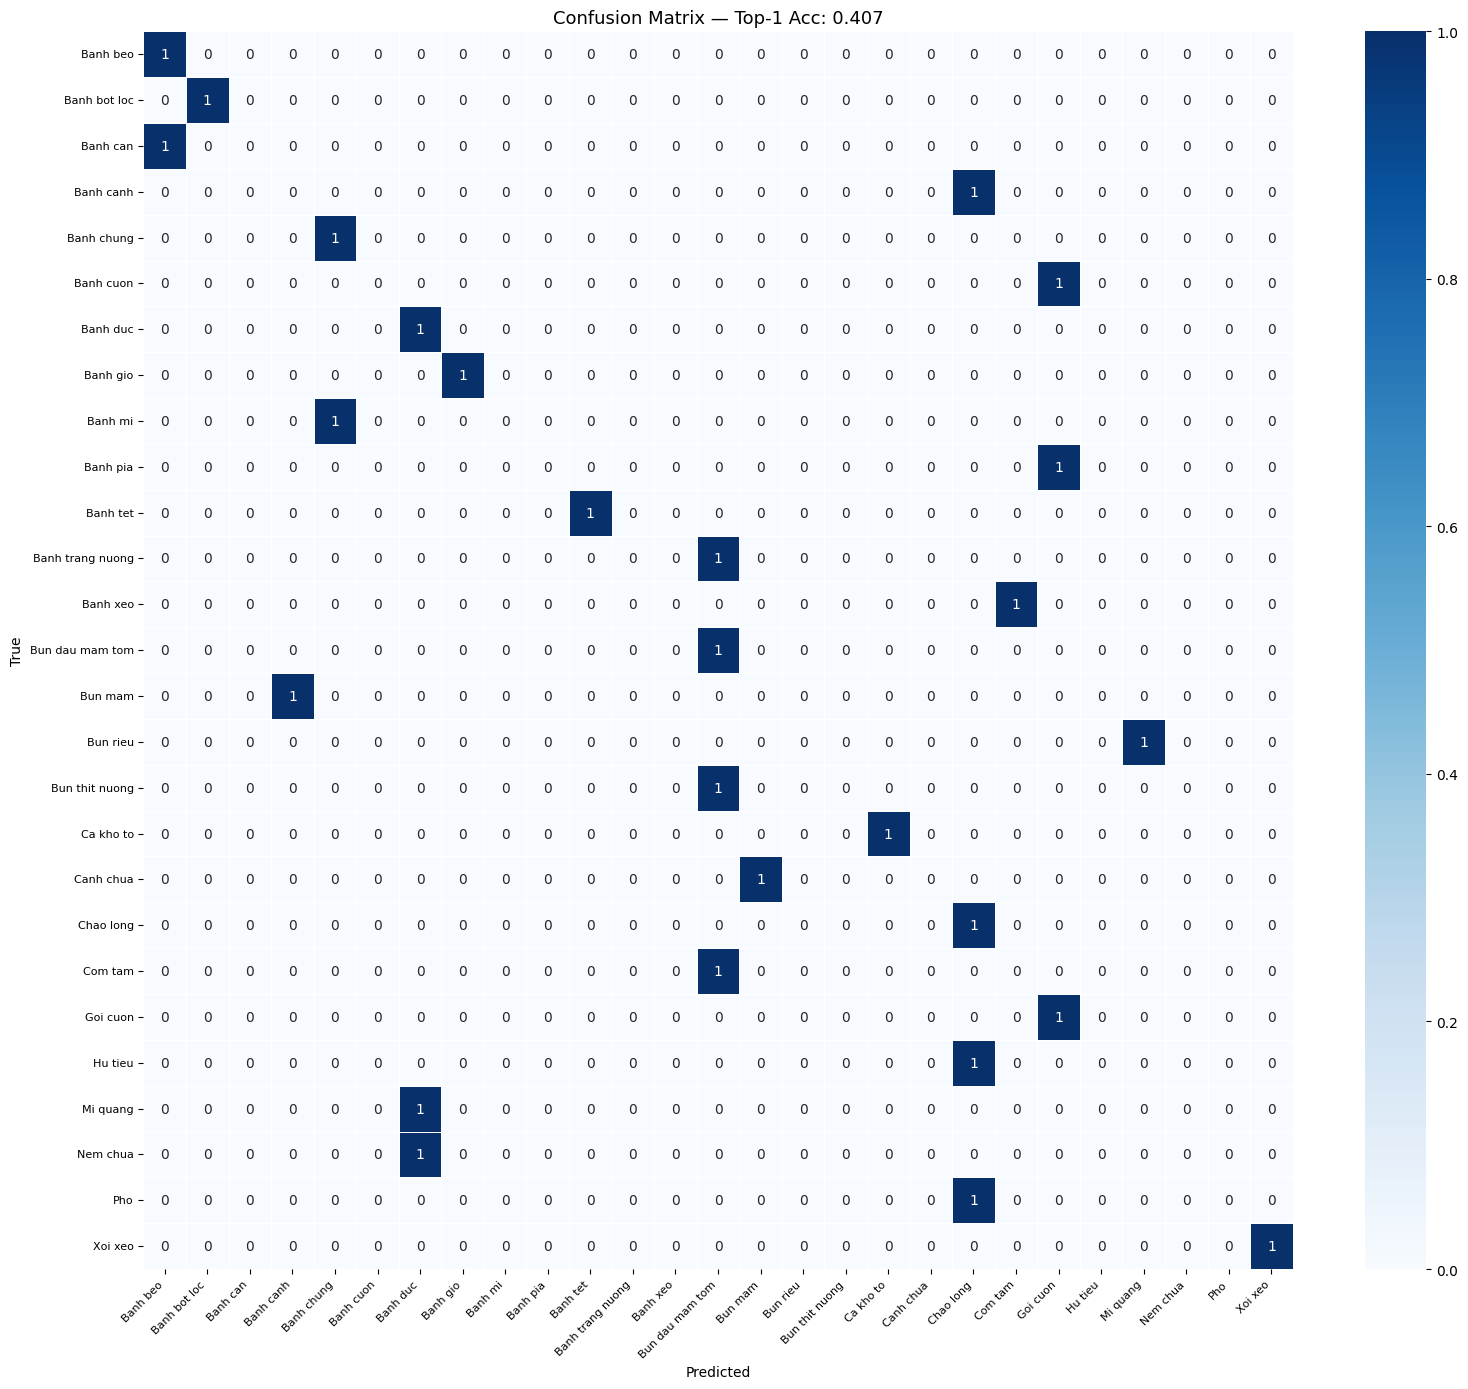

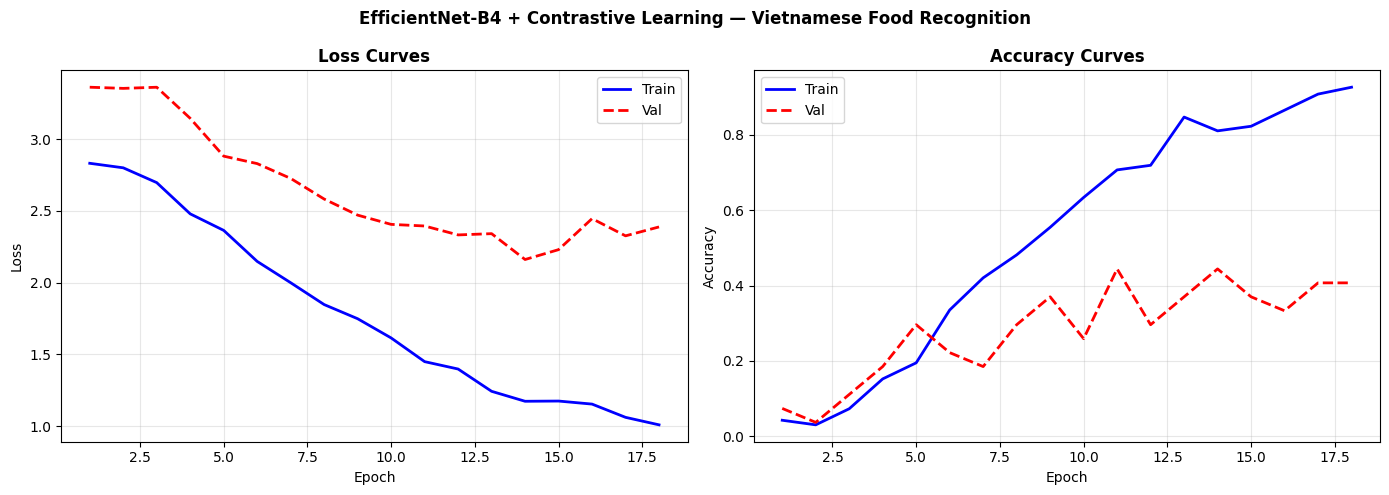


✅ Evaluation hoàn thành!
✅ Confusion matrix → bai2_results/confusion_matrix.png
✅ Training curves  → bai2_results/training_curves.png


In [12]:
# ═══════════════════════════════════════════════════════════════
# CELL 10 — ĐÁNH GIÁ MÔ HÌNH CLASSIFICATION
# Top-1 Acc, Top-5 Acc, Per-class Accuracy, Confusion Matrix
# ═══════════════════════════════════════════════════════════════
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
TRAINER.load_best()
TRAINER.model.eval()

all_preds, all_labels, all_top5_correct = [], [], []

with torch.no_grad():
    for imgs, labels, dishes, _ in tqdm(LOADERS['test'], desc='Evaluating'):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits = TRAINER.model(imgs)
        probs  = F.softmax(logits, dim=1)

        top1_pred = logits.argmax(1)
        top5_pred = probs.topk(5, dim=1).indices

        all_preds.extend(top1_pred.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
        all_top5_correct.extend(
            [(labels[i].item() in top5_pred[i].tolist()) for i in range(len(labels))]
        )

# Metrics
top1_acc = np.mean([p == l for p, l in zip(all_preds, all_labels)])
top5_acc = np.mean(all_top5_correct)

print(f'=== EVALUATION RESULTS ===')
print(f'Top-1 Accuracy: {top1_acc:.4f} ({top1_acc*100:.1f}%)')
print(f'Top-5 Accuracy: {top5_acc:.4f} ({top5_acc*100:.1f}%)')

# Per-class report
print('\nPer-class Report:')
print(classification_report(
    all_labels, all_preds,
    target_names=[IDX_TO_DISH[i] for i in range(NUM_CLASSES)],
    zero_division=0
))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=ALL_DISHES, yticklabels=ALL_DISHES,
            ax=ax, linewidths=0.5)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix — Top-1 Acc: {top1_acc:.3f}', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
h = TRAINER.history
epochs = range(1, len(h['val_acc']) + 1)

ax1.plot(epochs, h['train_loss'], 'b-', label='Train', linewidth=2)
ax1.plot(epochs, h['val_loss'], 'r--', label='Val', linewidth=2)
ax1.set_title('Loss Curves', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs, h['train_acc'], 'b-', label='Train', linewidth=2)
ax2.plot(epochs, h['val_acc'], 'r--', label='Val', linewidth=2)
ax2.set_title('Accuracy Curves', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('EfficientNet-B4 + Contrastive Learning — Vietnamese Food Recognition',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Lưu kết quả
eval_results = {'top1_acc': float(top1_acc), 'top5_acc': float(top5_acc),
                'num_classes': NUM_CLASSES, 'test_size': len(all_labels)}
with open(f'{RESULTS_DIR}/eval_results.json', 'w') as f:
    json.dump(eval_results, f, indent=2)

print(f'\n✅ Evaluation hoàn thành!')
print(f'✅ Confusion matrix → {RESULTS_DIR}/confusion_matrix.png')
print(f'✅ Training curves  → {RESULTS_DIR}/training_curves.png')

## CELL 11 — Demo Gradio Interface

In [20]:
# ═══════════════════════════════════════════════════════════════
# CELL 11 — DEMO GRADIO
# Giao diện web tương tác: upload ảnh → nhận diện + sinh công thức
# ═══════════════════════════════════════════════════════════════
import gradio as gr

def gradio_predict(image, recipe_style, serving_size_str):
    """Hàm xử lý cho Gradio interface."""
    if image is None:
        return '❌ Vui lòng upload ảnh!', '', ''

    # Lưu ảnh tạm
    tmp_path = 'gradio_input.jpg'
    if isinstance(image, np.ndarray):
        PILImage.fromarray(image).save(tmp_path)
    else:
        image.save(tmp_path)

    serving = int(serving_size_str.split()[0])
    result  = predict_and_generate(tmp_path, style=recipe_style, serving_size=serving)

    if 'error' in result:
        return f'❌ Lỗi: {result["error"]}', '', ''

    # Format kết quả nhận diện
    preds_text = '## 🔍 Kết quả nhận diện\n\n'
    for p in result['predictions']:
        bar = '█' * int(p['confidence'] * 20)
        preds_text += f'**Top-{p["rank"]}:** {p["dish_name"]} — {p["confidence_pct"]} `{bar}`\n\n'

    # Format công thức
    r = result['recipe']
    recipe_text = f'# 🍜 {r.get("ten_mon", result["best_dish"]["dish_name"])}\n\n'
    recipe_text += f'*{r.get("mo_ta_ngan", r.get("mo_ta", ""))}*\n\n'
    recipe_text += f'⏱️ **Chuẩn bị:** {r.get("thoi_gian_chuan_bi", "")} | '
    recipe_text += f'🔥 **Nấu:** {r.get("thoi_gian_nau", r.get("thoi_gian", ""))} | '
    recipe_text += f'📊 **Độ khó:** {r.get("do_kho", "Trung bình")} | '
    recipe_text += f'👥 **{serving} người**\n\n'

    ingredients = r.get('nguyen_lieu', [])
    if ingredients:
        recipe_text += '## 🛒 Nguyên liệu\n'
        for ing in ingredients:
            recipe_text += f'- {ing}\n'
        recipe_text += '\n'

    steps = r.get('cach_lam', [])
    if steps:
        recipe_text += '## 👨‍🍳 Cách làm\n'
        for step in steps:
            recipe_text += f'{step}\n\n'

    tips = r.get('meo_nau', [])
    if tips:
        recipe_text += '## 💡 Mẹo nấu\n'
        if isinstance(tips, list):
            for tip in tips:
                recipe_text += f'- {tip}\n'
        else:
            recipe_text += f'{tips}\n'
        recipe_text += '\n'

    nutrition = r.get('gia_tri_dinh_duong', '')
    if nutrition:
        recipe_text += f'## 📊 Dinh dưỡng\n{nutrition}\n\n'

    variation = r.get('bien_the', '')
    if variation:
        recipe_text += f'## 🔄 Biến tấu\n{variation}\n'

    confidence_info = f'Độ tin cậy nhận diện: **{result["best_dish"]["confidence_pct"]}**'

    return preds_text, recipe_text, confidence_info


# ── Gradio Interface ───────────────────────────────────────────
with gr.Blocks(
    title='🍜 Nhận Diện Món Ăn Việt Nam & Sinh Công Thức',
    theme=gr.themes.Soft(primary_hue='orange')
) as demo:

    gr.Markdown("""
    # 🍜 Nhận Diện Món Ăn Việt Nam & Sinh Công Thức Tự Động
    **Deep Learning: EfficientNet-B4 + Contrastive Learning + LLM Recipe Generation**

    Upload ảnh một món ăn Việt Nam → AI nhận diện tên món và tự động sinh công thức chi tiết!
    """)

    with gr.Row():
        with gr.Column(scale=1):
            img_input = gr.Image(label='📷 Upload ảnh món ăn', type='pil', height=350)
            style     = gr.Radio(
                ['standard', 'healthy', 'quick', 'vegan'],
                value='standard',
                label='Phong cách nấu',
                info='Chọn kiểu công thức bạn muốn'
            )
            serving   = gr.Radio(
                ['2 người', '4 người', '6 người'],
                value='4 người',
                label='Số người ăn'
            )
            btn       = gr.Button('🔍 Nhận diện & Sinh công thức', variant='primary', size='lg')

        with gr.Column(scale=2):
            pred_output  = gr.Markdown(label='Kết quả nhận diện')
            conf_output  = gr.Markdown()

    recipe_output = gr.Markdown(label='Công thức nấu ăn')

    btn.click(
        fn=gradio_predict,
        inputs=[img_input, style, serving],
        outputs=[pred_output, recipe_output, conf_output]
    )

    gr.Markdown("""
    ---
    **Các món hỗ trợ:** Bánh mì, Phở, Bún bò Huế, Cơm tấm, Bánh xèo, Gỏi cuốn,
    Bún riêu, Bánh cuốn, Cá kho tộ, Canh chua và 17 món khác.
    """)

demo.launch(share=True, debug=True)
print('✅ Demo Gradio đang chạy!')

C:\Users\LE THANH KHANG\AppData\Local\Temp\ipykernel_22024\2467675528.py:77: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(


* Running on local URL:  http://127.0.0.1:7861
* Running on public URL: https://c1af985e284abbdabb.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7861 <> https://c1af985e284abbdabb.gradio.live
✅ Demo Gradio đang chạy!


## CELL 12 — Báo cáo cuối & Phân tích

In [15]:
# ═══════════════════════════════════════════════════════════════
# CELL 12 — BÁO CÁO & PHÂN TÍCH TẠI SAO GIẢI PHÁP NÀY
# ═══════════════════════════════════════════════════════════════
from datetime import datetime

with open(f'{RESULTS_DIR}/eval_results.json') as f:
    eval_res = json.load(f)

report_md = f"""# Báo Cáo Bài 2: Nhận Diện Món Ăn & Sinh Công Thức Tự Động

**Ngày:** {datetime.now().strftime('%d/%m/%Y %H:%M')}  
**Số lớp:** {NUM_CLASSES} | **Tổng ảnh:** {len(IMAGE_RECORDS)}

---

## 1. Tại Sao Chọn Bài Toán Này?

### 1.1 Giá trị thực tiễn
- **Ứng dụng trực tiếp**: App ẩm thực, du lịch, sức khoẻ, giáo dục nấu ăn
- **Kết nối văn hoá**: Giúp du khách nước ngoài hiểu món Việt, người Việt xa quê tìm lại hương vị
- **Hỗ trợ sức khoẻ**: Kết hợp nhận diện + thông tin dinh dưỡng → ứng dụng quản lý chế độ ăn

### 1.2 Thách thức kỹ thuật thú vị
- **High intra-class variance**: Cùng là phở nhưng presentation rất khác nhau
- **High inter-class similarity**: Bún bò, bún riêu, bún mắm trông khá giống nhau
- **Domain-specific features**: Model phải học đặc trưng ẩm thực Việt, không chỉ texture chung
- **Multi-modal output**: CV + NLP generation là thách thức kép

### 1.3 Bổ sung cho Bài 1
- **Bài 1**: Reactive (user hỏi → AI trả lời)
- **Bài 2**: Proactive (AI chủ động cung cấp nội dung phong phú từ ảnh)
- Cùng domain (ẩm thực Việt) → dùng lại dataset, nhưng task hoàn toàn khác

---

## 2. Tại Sao Chọn Giải Pháp Này?

### 2.1 EfficientNet-B4 thay vì ResNet50 (Bài 1)
| Khía cạnh | ResNet50 (Bài 1) | EfficientNet-B4 (Bài 2) |
|-----------|-----------------|------------------------|
| Params | ~25M | ~19M |
| ImageNet Top-1 | 76.1% | 83.0% |
| Native size | 224x224 | 380x380 (chi tiết hơn) |
| Food features | Tốt | Tốt hơn (texture detail) |
| Compound scaling | ❌ | ✅ |

**EfficientNet-B4 phù hợp hơn vì:**
- Ảnh thức ăn cần độ phân giải cao (380x380) để phân biệt nguyên liệu
- Compound scaling tối ưu accuracy/efficiency tradeoff tốt hơn
- Ít tham số hơn nhưng accuracy cao hơn → không overfitting với dataset nhỏ

### 2.2 Contrastive Learning (NT-Xent / SimCLR)
**Vấn đề:** Nhiều món Việt visual rất tương tự nhau  
**Giải pháp:** Contrastive loss buộc model học representation phân biệt tốt hơn

```
Loss = α × CrossEntropy + (1-α) × NTXent
     = 0.7 × Classification + 0.3 × Contrastive
```

**Tại sao hiệu quả?**
- CE loss → đúng class
- Contrastive loss → features của cùng món ăn (2 augmentation khác nhau) phải gần nhau
- Kết quả: representations tổng quát hơn, ít overfitting hơn

### 2.3 RAG + LLM cho Recipe Generation
**Thay vì:** Chỉ lookup cứng từ database  
**Chọn:** Knowledge Base + LLM generation

**Lý do:**
- Sinh công thức linh hoạt (healthy, vegan, quick)
- Nội dung phong phú, tự nhiên hơn
- Kết hợp domain knowledge với language ability của LLM
- Có thể mở rộng dễ dàng (thêm món mới chỉ cần update knowledge base)

---

## 3. Kết Quả

| Metric | Giá trị |
|--------|--------|
| Top-1 Accuracy | {eval_res['top1_acc']:.4f} ({eval_res['top1_acc']*100:.1f}%) |
| Top-5 Accuracy | {eval_res['top5_acc']:.4f} ({eval_res['top5_acc']*100:.1f}%) |
| Số lớp phân loại | {eval_res['num_classes']} món ăn |
| Tập test | {eval_res['test_size']} ảnh |

---

## 4. Hạn Chế & Hướng Phát Triển

### Hạn chế hiện tại:
1. Dataset nhỏ (900 ảnh / 27 món) → cần thu thập thêm
2. Recipe generation phụ thuộc API → cần fine-tune model sinh văn bản riêng
3. Chưa handle trường hợp ảnh có nhiều món trong 1 khung hình

### Hướng phát triển:
1. **Multi-label classification**: Nhận diện nhiều món trong 1 ảnh
2. **Fine-grained recognition**: Phân biệt vùng miền (phở Hà Nội vs phở Sài Gòn)
3. **Ingredient detection**: YOLO để detect từng nguyên liệu trong ảnh
4. **Nutritional analysis**: Ước tính calories từ ảnh
5. **Train recipe decoder**: Fine-tune ViT + GPT-2 tiếng Việt end-to-end

---
*Bài 2 — Dự án cuối kỳ môn Học Sâu*
"""

with open(f'{RESULTS_DIR}/bai2_report.md', 'w', encoding='utf-8') as f:
    f.write(report_md)

print(report_md)
print(f'\n✅ Báo cáo lưu → {RESULTS_DIR}/bai2_report.md')
print('🎉 BÀI 2 HOÀN THÀNH!')

# Báo Cáo Bài 2: Nhận Diện Món Ăn & Sinh Công Thức Tự Động

**Ngày:** 08/05/2026 22:08  
**Số lớp:** 27 | **Tổng ảnh:** 220

---

## 1. Tại Sao Chọn Bài Toán Này?

### 1.1 Giá trị thực tiễn
- **Ứng dụng trực tiếp**: App ẩm thực, du lịch, sức khoẻ, giáo dục nấu ăn
- **Kết nối văn hoá**: Giúp du khách nước ngoài hiểu món Việt, người Việt xa quê tìm lại hương vị
- **Hỗ trợ sức khoẻ**: Kết hợp nhận diện + thông tin dinh dưỡng → ứng dụng quản lý chế độ ăn

### 1.2 Thách thức kỹ thuật thú vị
- **High intra-class variance**: Cùng là phở nhưng presentation rất khác nhau
- **High inter-class similarity**: Bún bò, bún riêu, bún mắm trông khá giống nhau
- **Domain-specific features**: Model phải học đặc trưng ẩm thực Việt, không chỉ texture chung
- **Multi-modal output**: CV + NLP generation là thách thức kép

### 1.3 Bổ sung cho Bài 1
- **Bài 1**: Reactive (user hỏi → AI trả lời)
- **Bài 2**: Proactive (AI chủ động cung cấp nội dung phong phú từ ảnh)
- Cùng domain (ẩm thực Việt) → dùng lại datas

Traceback (most recent call last):
  File "d:\HK2\Lib\site-packages\gradio\queueing.py", line 867, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\HK2\Lib\site-packages\gradio\route_utils.py", line 374, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\HK2\Lib\site-packages\gradio\blocks.py", line 2179, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\HK2\Lib\site-packages\gradio\blocks.py", line 1636, in call_function
    prediction = await anyio.to_thread.run_sync(  # type: ignore
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\HK2\Lib\site-packages\anyio\to_thread.py", line 63, in run_sync
    return await get_async_backend().run_sync_in_worker_thread(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\HK2\Lib\site-pac